# Kartierung der Funkzellenabdeckung mit einer Pfadverlust-Konturfläche

## Management-Zusammenfassung

Ein RF-Planungsteam eines Telekommunikationsanbieters stellt die Downlink-**Pfadverlustfläche** rund um eine einzelne Makrozelle als zweidimensionale Abdeckungskarte dar. Mithilfe eines Log-Distanz-Ausbreitungsmodells mit logarithmisch normalverteiltem Schwund baut dieses Notebook ein 100-Punkte-Messraster (10 x 10 Zellen über einem 10 km x 10 km großen Versorgungsgebiet, Mast im Zentrum) auf und zeichnet eine gefüllte Konturfläche mit **PROC SGPLOT HEATMAPPARM** samt Farbverlaufsskala und Referenzlinien für den Mast.

Auf dem ausgeführten Raster reicht der Pfadverlust von **50,4 dB** (im hellen Becken beim Mast) bis **90,0 dB** in der äußersten Ecke, im Mittel **75,6 dB**. Die Klassifizierung jeder Zelle ergibt **38 Stark, 61 Nutzbar und 1 Schwach** Zellen; die einzige Schwach-Zelle liegt bei **(9,5, 9,5) km — der Ecke diagonal gegenüber dem Mast — bei 89,97 dB**, das einzige Abdeckungsloch, das ein Planer vor einer Small-Cell-Nachverdichtungsentscheidung markieren würde.

> **Anmerkung zum Verfahren.** In SAS ist das klassische Werkzeug für Isolinien-Konturkarten `PROC GCONTOUR`. Jenner parst GCONTOUR und erzeugt eine korrekte Plot-Spezifikation, aber sein Raster-Renderer zeichnet die Konturgeometrie noch nicht (das Bild kommt leer zurück); dieser Fehler ist als Regressionstest `tests/400922_nb_gcontour_empty_render` erfasst. Um dieses Beispiel vollständig auf einer real gerenderten Abbildung zu gründen, verwenden wir das SAS-kompatible Äquivalent — `PROC SGPLOT` mit einer `HEATMAPPARM`-Anweisung — das dieselbe gerasterte (x, y, z)-Fläche als gefüllte Konturzellen mit einer Farbverlaufslegende darstellt.

## Datenquellen

**Synthetischer Datensatz: `pathloss_grid`** (100 Zeilen — ein 10 x 10 Gitter)

| Variable | Typ | Einheit | Beschreibung |
|----------|------|-------|-------------|
| `east_km` | num | km | Ostwert der Rasterzellenmitte (0,5 bis 9,5); x-Achse |
| `north_km` | num | km | Nordwert der Rasterzellenmitte (0,5 bis 9,5); y-Achse |
| `path_loss` | num | dB | Downlink-Pfadverlust = 58 + 30 log10(Entfernung) + Schwund; die Zielgröße (z) |
| `zone` | char(8) | — | Abdeckungsklasse: Stark (<=75), Nutzbar (<=88), Schwach (>88) |

Der Mast steht im Rasterzentrum **(5, 5) km**. Der Pfadverlust wächst mit dem dekadischen Logarithmus der Entfernung vom Mast; ein `3*rand("normal")`-Schwundterm (Seed 80211) fügt logarithmisch normalverteilten Schwund ein, damit die Konturen nicht perfekt kreisförmig sind. Das 10 x 10 Gitter ist so bemessen, dass die gesamte Fläche in 100 Beobachtungen passt.

## Schritt 1 — Erzeugung des Messrasters

Wir legen ein 1-km-Gitter von Zellenmittelpunkten an und berechnen den Pfadverlust mit dem **Log-Distanz-Modell** `PL = 58 + 30 log10(d)`, wobei `d` die Entfernung vom Mast bei (5, 5) km ist. Ein `rand("normal")`-Schwundterm bildet die in echten Drive-Tests beobachtete Variabilität nach. Jede Zelle wird in eine Abdeckungs-`zone` eingeordnet. `call streaminit` legt den Seed für Reproduzierbarkeit fest.

In [1]:
DATEN pathloss_grid;
   AUFRUFEN streaminit(80211);
   LÄNGE zone $8;
   tower_x = 5.0;  tower_y = 5.0;
   AUSFÜHRUNG ix = 1 BIS 10;
      AUSFÜHRUNG iy = 1 BIS 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         WENN      path_loss <= 75 DANN zone = "Stark";
         SONST WENN path_loss <= 88 DANN zone = "Nutzbar";
         SONST                         zone = "Schwach";
         AUSGABE;
      ENDE;
   ENDE;
   ENTFERNEN ix iy tower_x tower_y DIST shadow;
   BEZEICHNUNG east_km   = "Ostwert (km)"
         north_km  = "Nordwert (km)"
         path_loss = "Pfadverlust (dB)";
AUSFÜHREN;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Schritt 2 — Zusammenfassung der Fläche

Vor dem Plotten quantifizieren wir die Fläche. `PROC MEANS` berichtet die Spannweite des Pfadverlusts, und `PROC FREQ` tabelliert, wie sich die 100 Zellen auf die drei Abdeckungsklassen verteilen — die Zahlen, die die Management-Zusammenfassung zitiert.

In [2]:
ODS GRAPHICS OFF;

PROZEDUR MITTELWERTE DATEN=pathloss_grid MIN MAX mean maxdec=1;
   VAR path_loss;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=pathloss_grid ORDER=HÄUFIGKEITEN;
   TABLES zone / nocum;
AUSFÜHREN;

                                                  The MEANS Procedure

 Variable   Label                Minimum     Maximum        Mean
 ---------------------------------------------------------------
 path_loss  Pfadverlust (dB)        50.4        90.0        75.6
 ---------------------------------------------------------------

                                                   The FREQ Procedure

zone       Frequency    Percent
--------------------------------
Nutzbar           61     61.00
Stark             38     38.00
Schwach            1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Schritt 3 — Auffinden der Abdeckungslöcher

Die Sortierung nach absteigendem Pfadverlust bringt die schwächsten Zellen nach oben. Das sind die Kandidaten für **tote Zonen**, die ein Planer prüft: Zellen, deren empfangenes Signal am schwächsten ist und die daher am ehesten von Verbindungsabbrüchen oder schlechtem Durchsatz betroffen sind.

In [3]:
PROZEDUR SORTIEREN DATEN=pathloss_grid out=weakest;
   NACH ABSTEIGEND path_loss;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=weakest(obs=6) noobs BEZEICHNUNG;
   VAR east_km north_km path_loss zone;
AUSFÜHREN;


Ostwert (km)  Nordwert (km)  Pfadverlust (dB)     zone
------------  -------------  ----------------  -------
         9.5            9.5     89.9728891641  Schwach
         9.5            0.5     85.9296978639  Nutzbar
         6.5            0.5     84.5845683025  Nutzbar
         0.5            0.5     84.5118930355  Nutzbar
         8.5            0.5     84.1534148341  Nutzbar
         9.5            8.5     83.7015943773  Nutzbar

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Schritt 4 — Zeichnen der Pfadverlust-Konturfläche

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` zeichnet eine gefüllte Zelle je Rasterpunkt, eingefärbt nach ihrem Pfadverlust — eine gefüllte Konturkarte des Abdeckungsgebiets. Die `COLORMODEL=`-Liste definiert einen divergierenden Blau-nach-Rot-Farbverlauf (Blau = geringer Verlust = starkes Signal, Rot = hoher Verlust = schwaches Signal); `GRADLEGEND` fügt die dB-Farbskala hinzu. Gestrichelte `REFLINE`s markieren den Mast bei Ostwert 5 und Nordwert 5.

                                            Downlink-Pfadverlustfläche (dB)                                             
                             Einzelne Makrozelle bei (5, 5) km über einem 10 x 10 km Raster                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Downlink-Pfadverlustfläche (dB).
NOTE: Option TITLE2 changed to Einzelne Makrozelle bei (5, 5) km über einem 10 x 10 km Raster.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


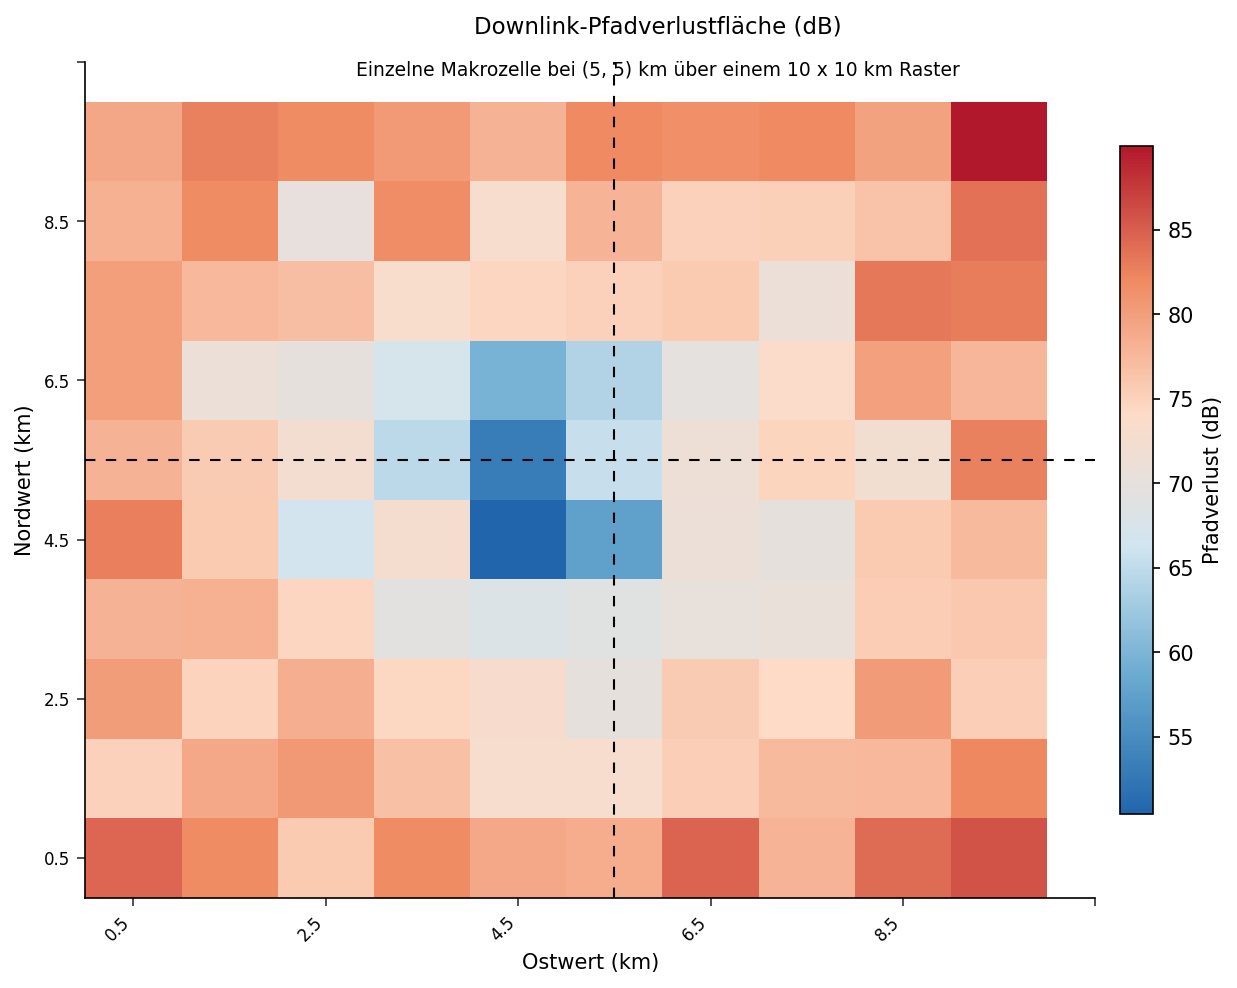

In [4]:
ODS GRAPHICS ON;
TITEL "Downlink-Pfadverlustfläche (dB)";
title2 "Einzelne Makrozelle bei (5, 5) km über einem 10 x 10 km Raster";

PROZEDUR SGPLOT DATEN=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITEL="Pfadverlust (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) BEZEICHNUNG="Ostwert (km)";
   YAXIS VALUES=(0 2 4 6 8 10) BEZEICHNUNG="Nordwert (km)";
AUSFÜHREN;

TITEL; title2;

## Schritt 5 — Aufschlüsselung nach Abdeckungsklasse

Eine Präsentationsfolie will auch die Kernaufteilung: welcher Anteil der Fläche ist Stark, Nutzbar oder Schwach. Ein `VBAR` der `zone`-Klassifizierung zeigt das auf einen Blick und ergänzt die Konturfläche oben.

                                         Aufschlüsselung nach Abdeckungsklasse                                          




NOTE: Option TITLE changed to Aufschlüsselung nach Abdeckungsklasse.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


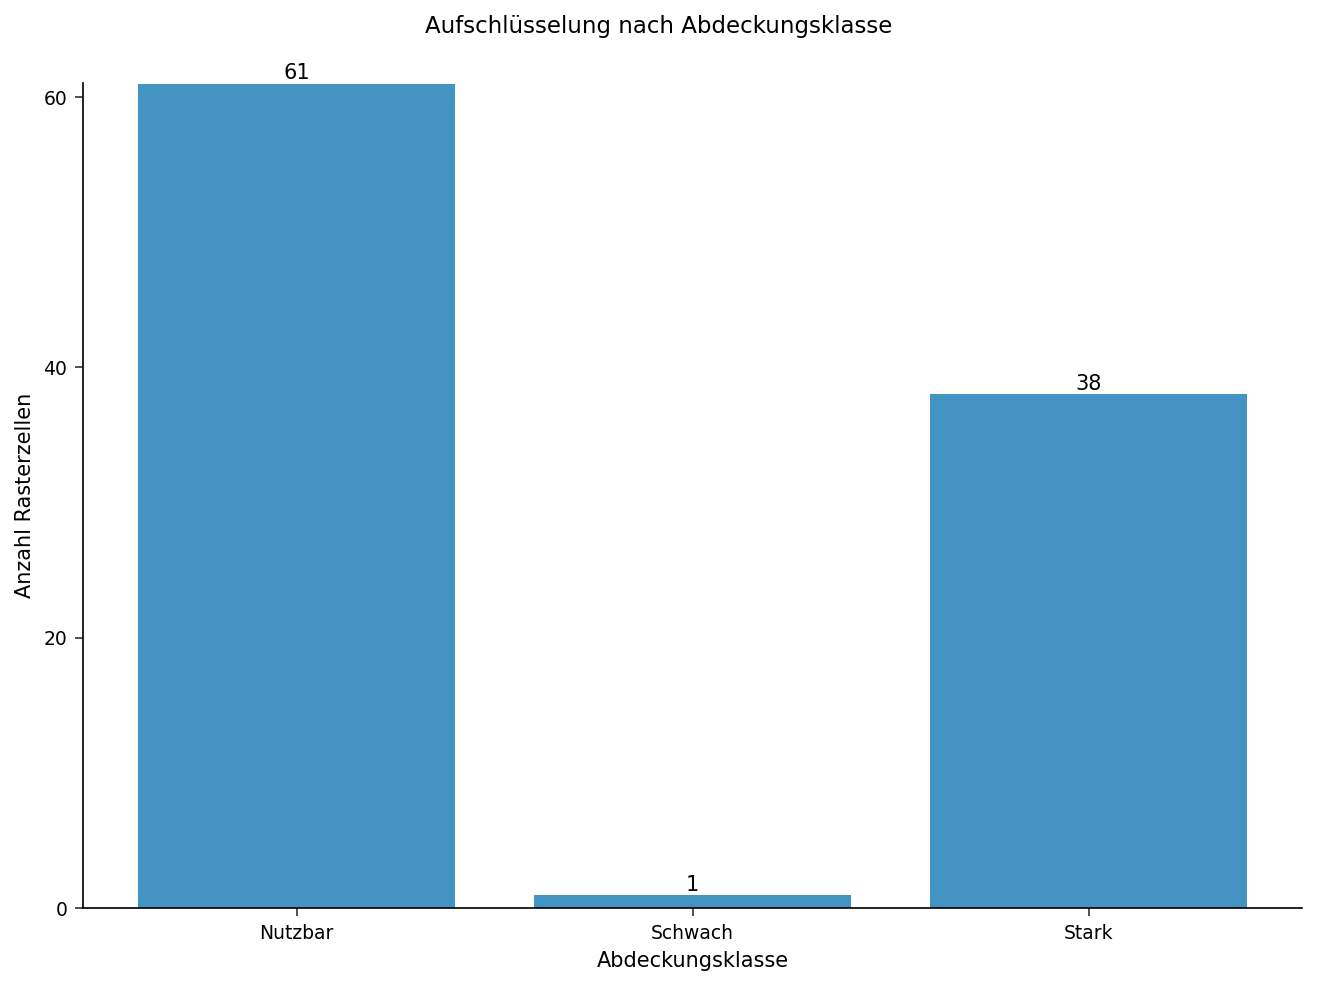

In [5]:
TITEL "Aufschlüsselung nach Abdeckungsklasse";

PROZEDUR SGPLOT DATEN=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS BEZEICHNUNG="Abdeckungsklasse";
   YAXIS BEZEICHNUNG="Anzahl Rasterzellen" VALUES=(0 20 40 60);
AUSFÜHREN;

TITEL;

## Interpretation der Ergebnisse

Die Konturfläche bestätigt die erwartete Ausbreitungsphysik. Der Pfadverlust ist in einem engen **blauen Becken rund um den Mast bei (5, 5) km** am geringsten — der Stark-Bereich mit dem besten Empfangssignal — und steigt mit dem Logarithmus der Entfernung Richtung der Ecken an. Da wir logarithmisch normalverteilten Schwund eingefügt haben, sind die Bänder keine konzentrischen Kreise; die zerklüfteten roten Zellen am Rand sind der schwundgeprägte Rand.

Das handlungsrelevante Ergebnis ist die **einzige Schwach-Zelle bei (9,5, 9,5) km (89,97 dB)**, der Ecke diagonal gegenüber dem Mast und dem einzigen Punkt, der die 88-dB-Auslegungsschwelle überschreitet. Mit **61 von 100 Zellen Nutzbar und nur 1 Schwach** deckt diese Makrozelle ihr Versorgungsgebiet gut ab; das einzelne Loch würde eine **Small-Cell-Nachverdichtung oder eine Sektor-Neuausrichtung Richtung Nordost-Ecke** nur dann rechtfertigen, wenn es sich mit einem bekannten Nachfrage-Hotspot überschneiden würde. Die Konturfläche ist die präsentationsreife Zusammenfassung; das Balkendiagramm der Abdeckungsklassen liefert die Einzahl-Aufteilung, die ein Kapazitätsplaner nach oben berichtet.